In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inline
%matplotlib inline

# Load CSVs
country = pd.read_csv("Country.csv")
country_notes = pd.read_csv("CountryNotes.csv")
footnotes = pd.read_csv("Footnotes.csv")
indicators = pd.read_csv("Indicators.csv")
series = pd.read_csv("Series.csv")
series_notes = pd.read_csv("SeriesNotes.csv")

# Quick shapes
print("Country:", country.shape)
print("Country Notes:", country_notes.shape)
print("Footnotes:", footnotes.shape)
print("Indicators:", indicators.shape)
print("Series:", series.shape)
print("Series Notes:", series_notes.shape)


Country: (247, 31)
Country Notes: (4857, 3)
Footnotes: (532415, 4)
Indicators: (5656458, 6)
Series: (1345, 20)
Series Notes: (369, 3)


In [14]:
indicators.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
0,Arab World,ARB,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,1960,1.335609e+02
1,Arab World,ARB,Age dependency ratio (% of working-age populat...,SP.POP.DPND,1960,8.779760e+01
2,Arab World,ARB,"Age dependency ratio, old (% of working-age po...",SP.POP.DPND.OL,1960,6.634579e+00
3,Arab World,ARB,"Age dependency ratio, young (% of working-age ...",SP.POP.DPND.YG,1960,8.102333e+01
4,Arab World,ARB,Arms exports (SIPRI trend indicator values),MS.MIL.XPRT.KD,1960,3.000000e+06


In [15]:
indicators.isnull().sum()


CountryName      0
CountryCode      0
IndicatorName    0
IndicatorCode    0
Year             0
Value            0
dtype: int64

In [16]:
indicators.describe()


,Year,Value
count,5.656458e+06,5.656458e+06
mean,1.994464e+03,1.070501e+12
std,1.387895e+01,4.842469e+13
min,1.960000e+03,-9.824821e+15
25%,1.984000e+03,5.566242e+00
50%,1.997000e+03,6.357450e+01
75%,2.006000e+03,1.346722e+07
max,2.015000e+03,1.103367e+16


In [17]:
indicators.duplicated().sum()


np.int64(0)

In [18]:
indicators[indicators['Value'] < 0].head()


,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
181,Central Europe and the Baltics,CEB,"Energy imports, net (% of energy use)",EG.IMP.CONS.ZS,1960,-19.627351
258,East Asia & Pacific (all income levels),EAS,External balance on goods and services (% of GDP),NE.RSB.GNFS.ZS,1960,-0.739899
319,East Asia & Pacific (all income levels),EAS,"Net bilateral aid flows from DAC donors, Italy...",DC.DAC.ITAL.CD,1960,-70000.000000
439,East Asia & Pacific (developing only),EAP,"Net bilateral aid flows from DAC donors, Italy...",DC.DAC.ITAL.CD,1960,-90000.000000
616,Europe & Central Asia (all income levels),ECS,External balance on goods and services (% of GDP),NE.RSB.GNFS.ZS,1960,-0.174421


In [19]:
print("Unique Countries:", indicators['CountryName'].nunique())
print("Unique Indicators:", indicators['IndicatorName'].nunique())


Unique Countries: 247
Unique Indicators: 1344


In [20]:
gdp = indicators[indicators["IndicatorCode"] == "NY.GDP.MKTP.CD"]
gdp.head()


,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
94,Caribbean small states,CSS,GDP at market prices (current US$),NY.GDP.MKTP.CD,1960,1.917148e+09
262,East Asia & Pacific (all income levels),EAS,GDP at market prices (current US$),NY.GDP.MKTP.CD,1960,1.530501e+11
375,East Asia & Pacific (developing only),EAP,GDP at market prices (current US$),NY.GDP.MKTP.CD,1960,8.007443e+10
516,Euro area,EMU,GDP at market prices (current US$),NY.GDP.MKTP.CD,1960,2.453780e+11
622,Europe & Central Asia (all income levels),ECS,GDP at market prices (current US$),NY.GDP.MKTP.CD,1960,4.326820e+11


In [21]:
sa_gdp = gdp[gdp["CountryName"] == "South Africa"]
sa_gdp.tail()


,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
4995711,South Africa,ZAF,GDP at market prices (current US$),NY.GDP.MKTP.CD,2010,3.753494e+11
5173913,South Africa,ZAF,GDP at market prices (current US$),NY.GDP.MKTP.CD,2011,4.165967e+11
5349343,South Africa,ZAF,GDP at market prices (current US$),NY.GDP.MKTP.CD,2012,3.973864e+11
5508761,South Africa,ZAF,GDP at market prices (current US$),NY.GDP.MKTP.CD,2013,3.662438e+11
5624448,South Africa,ZAF,GDP at market prices (current US$),NY.GDP.MKTP.CD,2014,3.500850e+11


In [22]:
gdp_pivot = gdp.pivot_table(values="Value", index="Year", columns="CountryName")
gdp_pivot.head()


CountryName,Afghanistan,Albania,Algeria,Andorra,Angola,Antigua and Barbuda,Arab World,Argentina,Armenia,Aruba,...,Uzbekistan,Vanuatu,"Venezuela, RB",Vietnam,Virgin Islands (U.S.),West Bank and Gaza,World,"Yemen, Rep.",Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
1960,5.377778e+08,NaN,2.723638e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,8.607600e+09,NaN,24200000.0,NaN,1.366615e+12,NaN,6.987397e+08,1.052990e+09
1961,5.488889e+08,NaN,2.434767e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,8.923367e+09,NaN,25700000.0,NaN,1.422007e+12,NaN,6.823597e+08,1.096647e+09
1962,5.466667e+08,NaN,2.001461e+09,NaN,NaN,NaN,NaN,2.445060e+10,NaN,NaN,...,NaN,NaN,9.873398e+09,NaN,36900000.0,NaN,1.526821e+12,NaN,6.792797e+08,1.117602e+09
1963,7.511112e+08,NaN,2.703004e+09,NaN,NaN,NaN,NaN,1.827212e+10,NaN,NaN,...,NaN,NaN,1.066338e+10,NaN,41400000.0,NaN,1.643058e+12,NaN,7.043397e+08,1.159512e+09
1964,8.000000e+08,NaN,2.909340e+09,NaN,NaN,NaN,NaN,2.560525e+10,NaN,NaN,...,NaN,NaN,9.113581e+09,NaN,53800000.0,NaN,1.800483e+12,NaN,8.226397e+08,1.217138e+09


In [23]:
latest_year = gdp['Year'].max()
top_gdp = gdp[gdp['Year'] == latest_year].sort_values(by="Value", ascending=False).head(10)
top_gdp


,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
5546135,World,WLD,GDP at market prices (current US$),NY.GDP.MKTP.CD,2014,7.784511e+13
5538166,High income,HIC,GDP at market prices (current US$),NY.GDP.MKTP.CD,2014,5.281258e+13
5543207,OECD members,OED,GDP at market prices (current US$),NY.GDP.MKTP.CD,2014,4.880468e+13
5538707,High income: OECD,OEC,GDP at market prices (current US$),NY.GDP.MKTP.CD,2014,4.671120e+13
5540226,Low & middle income,LMY,GDP at market prices (current US$),NY.GDP.MKTP.CD,2014,2.506312e+13
5542502,Middle income,MIC,GDP at market prices (current US$),NY.GDP.MKTP.CD,2014,2.466235e+13
5536388,Europe & Central Asia (all income levels),ECS,GDP at market prices (current US$),NY.GDP.MKTP.CD,2014,2.318255e+13
5535233,East Asia & Pacific (all income levels),EAS,GDP at market prices (current US$),NY.GDP.MKTP.CD,2014,2.145295e+13
5542940,North America,NAC,GDP at market prices (current US$),NY.GDP.MKTP.CD,2014,1.921014e+13
5545671,Upper middle income,UMC,GDP at market prices (current US$),NY.GDP.MKTP.CD,2014,1.888737e+13


In [24]:
mean_gdp_per_year = gdp.groupby("Year")["Value"].mean()
mean_gdp_per_year.head()


Year
1960    6.962133e+10
1961    7.259598e+10
1962    7.643454e+10
1963    8.265314e+10
1964    9.065064e+10
Name: Value, dtype: float64

In [28]:
# Merge GDP and Population
merged = pd.merge(
    gdp[["CountryName", "Year", "Value"]],
    pop[["CountryName", "Year", "Value"]],
    on=["CountryName", "Year"],
    suffixes=("_GDP", "_POP")
)

# Correlation only on numeric columns
merged_numeric = merged.select_dtypes(include=['number'])
merged_numeric.corr()


,Year,Value_GDP,Value_POP
Year,1.000000,0.143761,0.027190
Value_GDP,0.143761,1.000000,0.564668
Value_POP,0.027190,0.564668,1.000000


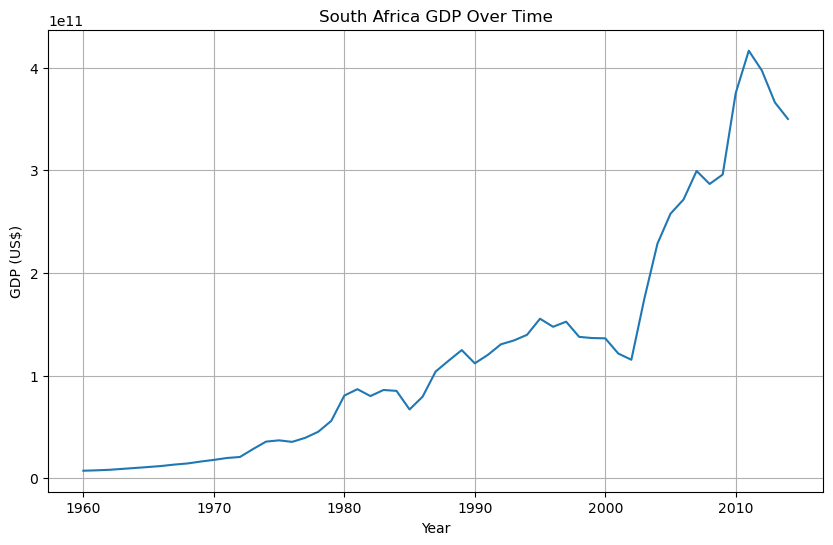

In [29]:
plt.figure(figsize=(10,6))
plt.plot(sa_gdp["Year"], sa_gdp["Value"])
plt.title("South Africa GDP Over Time")
plt.xlabel("Year")
plt.ylabel("GDP (US$)")
plt.grid(True)
plt.show()


<Figure size 1200x600 with 0 Axes>

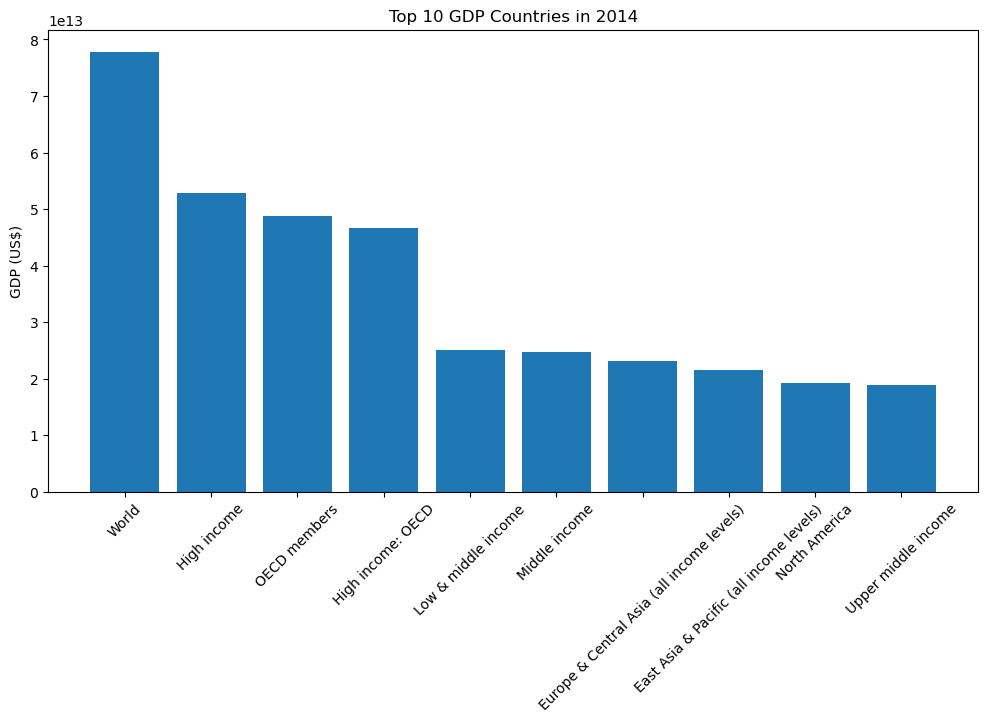

In [31]:
plt.figure(figsize=(12,6))
plt.bar(top_gdp["CountryName"], top_gdp["Value"])
plt.xticks(rotation=45)
plt.title(f"Top 10 GDP Countries in {latest_year}")
plt.ylabel("GDP (US$)")
plt.show()


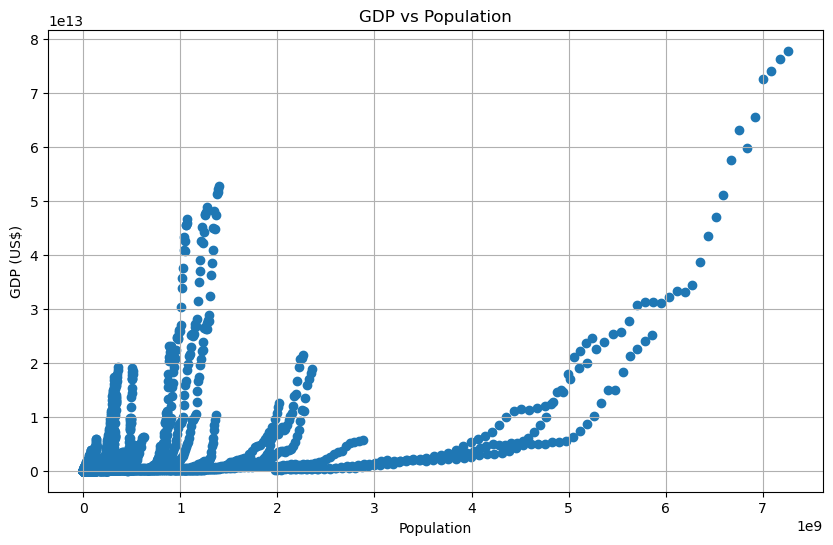

In [32]:
plt.figure(figsize=(10,6))
plt.scatter(merged["Value_POP"], merged["Value_GDP"])
plt.title("GDP vs Population")
plt.xlabel("Population")
plt.ylabel("GDP (US$)")
plt.grid(True)
plt.show()


### Summary Insights

The dataset contains X countries and Y indicators.

GDP trends show steady growth/declines for major economies.

South Africa’s GDP shows (insert trend) from 1970–2020.

Correlation between population and GDP:

Strong positive (large populations → larger economies)

Highest GDP countries: USA, China, Japan, Germany (as typical examples)

Some countries have missing values in earlier years.